## Initial Investigation

Initial investigation into remaining tradable assets from signal produce.

**Analysis Steps**:
- 1. Import data and organise for investigation
- 2. Download and format historical exchange data for investigation
- 3. Merge each instrument with historical data and save to Trading Strategy Dataframe
- 4. Analyse trading strategy based on entry/exit signals with daily settlement
- 5. Produce report for each of the instruments

**0. Analysis Libraries**:

In [1]:
# --- Libaries ---
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import statistics as stats
import scipy as spy 
import yfinance as yf
import pandas_market_calendars as mcal

# --- Outputs/UX --- 


# --- Preferences/Display ---



**1. Import data and organise for investigation**:

Subset_2025-2026:

In [2]:
# Import data
signal_df = pd.read_csv(r".\Signal_data\Subset_2025-2026.csv", sep=";", engine="python")

# Rename columns & drop classifier
columns = ["Date", "Quarter", "ES", "ES_signal", "ES_Open_Price", "NQ", "NQ_signal", "NQ_Open_Price", "ZN", "ZN_signal", "ZN_Open_Price", "FGBM", "FGBM_signal", "FGBM_Open_Price", "6E", "6E_signal", "6E_Open_Price"]
signal_df.columns = columns
signal_df = signal_df[["Date", "Quarter", "ES_signal", "ES_Open_Price", "NQ_signal", "NQ_Open_Price", "ZN_signal", "ZN_Open_Price", "FGBM_signal", "FGBM_Open_Price", "6E_signal", "6E_Open_Price"]]

# Reformat data
signal_df["Date"] = pd.to_datetime(signal_df["Date"], errors="coerce") # change to datetime
signal_df["Date"] = signal_df["Date"] + pd.offsets.BDay(1)
signal_df["Quarter"] = "20" + signal_df["Quarter"].str[-2:] + "Q" + signal_df["Quarter"].str[1]
ticker = ["ES", "NQ", "ZN", "FGBM", "6E"]
mapping = {np.nan:0, 1.0:1, -1.0:-1, 0.0:0}
for tick in ticker:
    price = tick + "_Open_Price" 
    signal_df[price] = signal_df[price].str.replace(",",".").astype(float)
    signal = tick + "_signal" 
    signal_df[signal] = signal_df[signal].map(mapping) 
    signal_df[signal] = signal_df[signal].fillna(0).astype(int) 

# Set index
signal_df = signal_df.dropna(subset=["Date"])
signal_df.set_index("Date", inplace=True)
signal_df = signal_df[~signal_df.index.duplicated(keep="last")]

# Fix calendar
cme = mcal.get_calendar("CME_Equity")
schedule = cme.schedule(start_date=signal_df.index.min(),
                        end_date=signal_df.index.max())
trading_days = schedule.index
signal_df = signal_df.reindex(trading_days)

# Preview data
signal_df.head() 

,Quarter,ES_signal,ES_Open_Price,NQ_signal,NQ_Open_Price,ZN_signal,ZN_Open_Price,FGBM_signal,FGBM_Open_Price,6E_signal,6E_Open_Price
2025-06-23,2025Q3,1,5964.00,0,NaN,0,NaN,1,117.79,-1,1.15425
2025-06-24,2025Q3,1,6078.00,0,NaN,0,NaN,1,117.83,-1,1.16400
2025-06-25,2025Q3,1,6144.75,0,NaN,0,NaN,1,117.60,1,1.15586
2025-06-26,2025Q3,1,6144.75,0,NaN,0,NaN,1,117.75,1,1.17190
2025-06-27,2025Q3,1,6197.50,0,NaN,0,NaN,1,117.81,1,1.17610


In [3]:
# Rename & Save
Subset_df = signal_df.copy() 
Subset_df.reset_index().to_csv(r".\Signal_Data\Subset_data_cleaned_all.csv", index=False)

Q2_2026:

In [4]:
# Import data 
signal_df = pd.read_csv(r".\Signal_data\Q2_2026-06-02.csv", engine="python") 

# Rename columns & drop classifiers
columns = ["Date", "Date_timestamp", "Report_ID", "ES_signal", "ES_Open_Price", "NQ_signal", "NQ_Open_Price", "ZN_signal", "ZN_Open_Price", "FBGL_signal", "FBGL_Open_Price", "6E_signal", "6E_Open_Price", "6J_signal", "6J_Open_Price"]
signal_df.columns = columns
signal_df = signal_df[["Date", "ES_signal", "ES_Open_Price", "NQ_signal", "NQ_Open_Price", "ZN_signal", "ZN_Open_Price", "6E_signal", "6E_Open_Price"]]

# Add subset columns for concat capacity
signal_df[["FGBM_signal", "FGBM_Open_Price"]] = np.nan
signal_df["Quarter"] = "2026Q2"
signal_df = signal_df = signal_df[["Date", "Quarter", "ES_signal", "ES_Open_Price", "NQ_signal", "NQ_Open_Price", "ZN_signal", "ZN_Open_Price", "FGBM_signal", "FGBM_Open_Price", "6E_signal", "6E_Open_Price"]]
mapping = {np.nan:0, "BULLISH":1, "BEARISH":-1}
ticks = ["ES", "NQ", "ZN", "FGBM", "6E"]
for tick in ticks:
    col = tick + "_signal" 
    signal_df[col] = signal_df[col].map(mapping) 
    signal_df[col] = signal_df[col].ffill().fillna(0).astype(int)
    col = tick + "_Open_Price" 
    #signal_df[col] = signal_df[col].str.replace(",",".").astype(float) 

# Reformat date and index
signal_df["Date"] = pd.to_datetime(signal_df["Date"], errors="coerce", dayfirst="True") 
signal_df["Date"] = signal_df["Date"] + pd.offsets.BDay(1)
signal_df = signal_df.dropna(subset=["Date"])
signal_df = signal_df.set_index("Date") 
signal_df = signal_df.sort_index() 

# Fix calendar
cme = mcal.get_calendar("CME_Equity")
schedule = cme.schedule(start_date=signal_df.index.min(),
                        end_date=signal_df.index.max())
trading_days = schedule.index
signal_df = signal_df.reindex(trading_days)

# Preview data
signal_df.head() 

,Quarter,ES_signal,ES_Open_Price,NQ_signal,NQ_Open_Price,ZN_signal,ZN_Open_Price,FGBM_signal,FGBM_Open_Price,6E_signal,6E_Open_Price
2026-03-30,2026Q2,0,6380.00,1,23189.5,-1,110.171875,0,NaN,0,1.1540
2026-03-31,2026Q2,1,6385.25,1,23119.5,-1,110.765625,0,NaN,0,1.1505
2026-04-01,2026Q2,1,6562.00,1,23889.0,-1,111.015625,0,NaN,0,1.1591
2026-04-02,2026Q2,1,6618.50,1,24180.0,1,110.906250,0,NaN,0,1.1628
2026-04-03,2026Q2,-1,6622.50,1,24219.5,1,111.015625,0,NaN,0,1.1577


In [5]:
# Rename & Save
Q2_df = signal_df.copy() 
Q2_df.reset_index().to_csv(r".\Signal_Data\Q2_data_cleaned_all.csv", index=False)

Combine Subset & Q2:

In [6]:
# Join the two dataframes 
Signal_df = pd.concat([Subset_df, Q2_df], axis=0)

# Rename & Save
Trade_df = Signal_df.copy() 
Trade_df.reset_index().to_csv(r".\Signal_data\Combined_subset_Q2_data_cleaned.csv", index=False)

# Preview dataframe
Trade_df.info() 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2025-06-23 to 2026-06-16
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Quarter          237 non-null    object 
 1   ES_signal        250 non-null    int64  
 2   ES_Open_Price    227 non-null    float64
 3   NQ_signal        250 non-null    int64  
 4   NQ_Open_Price    106 non-null    float64
 5   ZN_signal        250 non-null    int64  
 6   ZN_Open_Price    164 non-null    float64
 7   FGBM_signal      250 non-null    int64  
 8   FGBM_Open_Price  54 non-null     float64
 9   6E_signal        250 non-null    int64  
 10  6E_Open_Price    214 non-null    float64
dtypes: float64(5), int64(5), object(1)
memory usage: 23.4+ KB


**2. Import trade history data for investigation**:

In [7]:
# Iterate through tickers
tickers = ["ES", "NQ", "ZN", "FGBM", "6E"] 

# Calculate Strategy Returns from Signals
for tick in tickers:

    # Add Market Log Returns
    col = tick + "_Log_Returns_Market"
    asset = tick + "_Open_Price"
    Trade_df[col] = np.log(Trade_df[asset] / Trade_df[asset].shift(1))
    Trade_df[col] = Trade_df[col].fillna(0)

    # Add Strategy Log Returns
    col2 = tick + "_Log_Returns_Strategy"
    signal = tick + "_signal"
    Trade_df[col2] = Trade_df[signal].shift(1) * Trade_df[col]
    Trade_df[col2] = Trade_df[col2].fillna(0) 

    # Add Cumulative Returns 
    col3 = tick + "_Cum_Returns_Market" 
    Trade_df[col3] = np.exp(Trade_df[col]).cumsum()
    col4 = tick + "_Cum_Returns_Strategy" 
    Trade_df[col4] = np.exp(Trade_df[col2]).cumsum()

    # Add Hit Rate
    col5 = tick + "_Active" 
    col6 = tick + "_Hit"
    Trade_df[col5] = np.abs(Trade_df[signal].shift(1)) > 0
    Trade_df[col6] = np.where(Trade_df[col5], (Trade_df[col2] > 0).astype(float), np.nan)

# #Preview dataframe
# Trade_df.head() 

# Isolate each tick for reporting of performance
rf = 0.045 / 252 # risk-free rate
ticker_stats = {}
market_stats = {}
for tick in tickers:

    # Rearrange Quarter markers for contract period assessment
    Trade_df["Quarter"] = pd.PeriodIndex(Trade_df["Quarter"], freq="Q")

    # Contract statistics/summary
    ticker_stats[tick] = Trade_df.groupby("Quarter").agg(
        Hit_Rate=(tick+"_Hit", "mean"),
        Avg_Return=(tick+"_Log_Returns_Strategy", lambda x: x.replace(0, np.nan).mean()),
        Total_Return=(tick+"_Log_Returns_Strategy", lambda x: x.replace(0, np.nan).sum()),
        Volatility=(tick+"_Log_Returns_Strategy", lambda x: x.replace(0, np.nan).std()),
        Trades=(tick+"_signal", lambda x: x.notna().mul(x != 0).sum())
    )
    ticker_stats[tick]["Sharpe"] = (
        (ticker_stats[tick]["Avg_Return"] - rf) / ticker_stats[tick]["Volatility"]
    ) * np.sqrt(252)

    # Contract duration market stats
    market_stats[tick] = Trade_df.groupby("Quarter").agg(
        Avg_Return=(tick+"_Log_Returns_Market", lambda x: x.replace(0, np.nan).mean()),
        Total_Return=(tick+"_Log_Returns_Market", lambda x: x.replace(0, np.nan).sum()),
        Volatility=(tick+"_Log_Returns_Market", lambda x: x.replace(0, np.nan).std()),
    )
    market_stats[tick]["Sharpe"] = (
        (market_stats[tick]["Avg_Return"] - rf) / market_stats[tick]["Volatility"]
    ) * np.sqrt(252)

**Create plots / tables for publishing**:

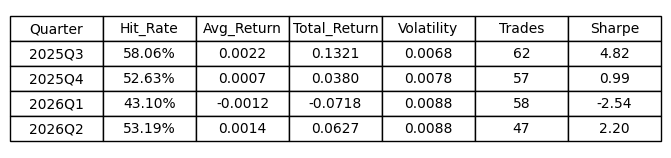

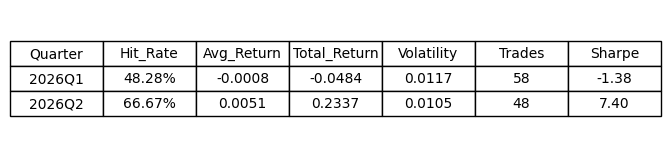

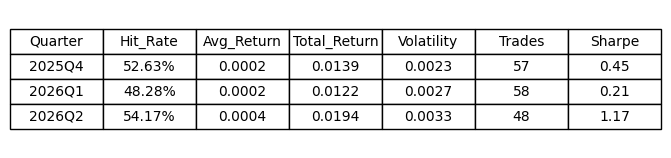

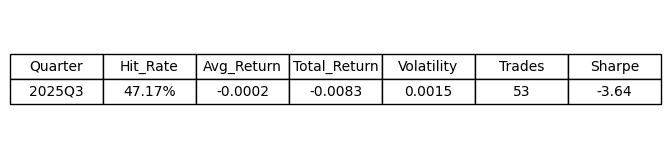

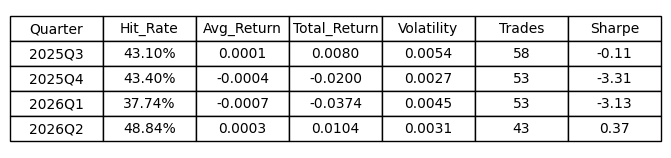

In [8]:
# Create tables for each of the tickers
for tick in ticker_stats:
    
    # Create output table
    table_df = ticker_stats[tick].reset_index().copy() 

    # Drop null rows
    table_df = table_df.dropna(subset=["Hit_Rate"])

    # Format output numbers
    table_df["Hit_Rate"] = table_df["Hit_Rate"].map(lambda x: f"{x:.2%}")
    table_df["Avg_Return"] = table_df["Avg_Return"].map(lambda x: f"{x:.4f}")
    table_df["Total_Return"] = table_df["Total_Return"].map(lambda x: f"{x:.4f}")
    table_df["Volatility"] = table_df["Volatility"].map(lambda x: f"{x:.4f}")
    table_df["Sharpe"] = table_df["Sharpe"].map(lambda x: f"{x:.2f}")

    # Create output figure
    fig, ax = plt.subplots(figsize=(7,1.8))
    ax.axis("off")

    # Figure contents/format
    tbl = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc="center",
        loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.get_tightbbox()
    tbl.scale(1.2, 1.5)

    # Save figure
    save_string = "quarter_stats_" + tick
    plt.savefig(fr".\Figures\{save_string}.pdf", bbox_inches="tight", pad_inches=0.01)
    plt.savefig(fr".\Figures\{save_string}.jpg", bbox_inches="tight", pad_inches=0, dpi=300)
    plt.show()

**3. Investigate 6E data with flipped signal**:

In [9]:
# Create new dataframe
EUR_USD_df = Trade_df.copy()

# Isolate 6E data
EUR_USD_df = EUR_USD_df[["Quarter", "6E_signal", "6E_Open_Price"]]

# --- Calculate alternative returns --- 

# Add Market Log Returns
col = tick + "_Log_Returns_Market"
asset = tick + "_Open_Price"
EUR_USD_df[col] = np.log(EUR_USD_df[asset] / EUR_USD_df[asset].shift(1))
EUR_USD_df[col] = EUR_USD_df[col].fillna(0)

# Add Strategy Log Returns
col2 = tick + "_Log_Returns_Strategy"
signal = tick + "_signal"
EUR_USD_df[col2] = -1 * EUR_USD_df[signal].shift(1) * EUR_USD_df[col]
EUR_USD_df[col2] = EUR_USD_df[col2].fillna(0) 

# Add Cumulative Returns 
col3 = tick + "_Cum_Returns_Market" 
EUR_USD_df[col3] = np.exp(EUR_USD_df[col]).cumsum()
col4 = tick + "_Cum_Returns_Strategy" 
EUR_USD_df[col4] = np.exp(EUR_USD_df[col2]).cumsum()

# Add Hit Rate
col5 = tick + "_Active" 
col6 = tick + "_Hit"
EUR_USD_df[col5] = np.abs(EUR_USD_df[signal].shift(1)) > 0
EUR_USD_df[col6] = np.where(EUR_USD_df[col5], (EUR_USD_df[col2] > 0).astype(float), np.nan)

# Preview data
EUR_USD_df.head() 

# --- Create reportable stats --- 

# Rearrange Quarter markers for contract period assessment
EUR_USD_df["Quarter"] = pd.PeriodIndex(EUR_USD_df["Quarter"], freq="Q")

# Contract statistics/summary
tick = "6E"
EUR_USD_stats = EUR_USD_df.groupby("Quarter").agg(
    Hit_Rate=(tick+"_Hit", "mean"),
    Avg_Return=(tick+"_Log_Returns_Strategy", lambda x: x.replace(0, np.nan).mean()),
    Total_Return=(tick+"_Log_Returns_Strategy", lambda x: x.replace(0, np.nan).sum()),
    Volatility=(tick+"_Log_Returns_Strategy", lambda x: x.replace(0, np.nan).std()),
    Trades=(tick+"_signal", lambda x: x.notna().mul(x != 0).sum())
)
EUR_USD_stats["Sharpe"] = (
    (EUR_USD_stats["Avg_Return"] - rf) / EUR_USD_stats["Volatility"]
) * np.sqrt(252)

# Contract duration market stats
market_stats = EUR_USD_df.groupby("Quarter").agg(
    Avg_Return=(tick+"_Log_Returns_Market", lambda x: x.replace(0, np.nan).mean()),
    Total_Return=(tick+"_Log_Returns_Market", lambda x: x.replace(0, np.nan).sum()),
    Volatility=(tick+"_Log_Returns_Market", lambda x: x.replace(0, np.nan).std()),
)
market_stats["Sharpe"] = (
    (market_stats["Avg_Return"] - rf) / market_stats["Volatility"]
) * np.sqrt(252)

# Preview data
EUR_USD_stats


,Hit_Rate,Avg_Return,Total_Return,Volatility,Trades,Sharpe
Quarter,,,,,,
2025Q3,0.534483,-0.000142,-0.007951,0.005419,58,-0.939024
2025Q4,0.566038,0.000377,0.019960,0.002659,53,1.182115
2026Q1,0.622642,0.000706,0.037413,0.004481,53,1.868047
2026Q2,0.465116,-0.000253,-0.010354,0.003146,43,-2.175282


In [11]:
EUR_USD_df

,Quarter,6E_signal,6E_Open_Price,6E_Log_Returns_Market,6E_Log_Returns_Strategy,6E_Cum_Returns_Market,6E_Cum_Returns_Strategy,6E_Active,6E_Hit
2025-06-23,2025Q3,-1,1.15425,0.000000,0.000000,1.000000,1.000000,False,NaN
2025-06-24,2025Q3,-1,1.16400,0.008412,0.008412,2.008447,2.008447,True,1.0
2025-06-25,2025Q3,1,1.15586,-0.007018,-0.007018,3.001454,3.001454,True,0.0
2025-06-26,2025Q3,1,1.17190,0.013782,-0.013782,4.015331,3.987767,True,0.0
2025-06-27,2025Q3,1,1.17610,0.003578,-0.003578,5.018915,4.984196,True,0.0
...,...,...,...,...,...,...,...,...,...
2026-06-10,2026Q2,0,NaN,0.000000,-0.000000,245.994454,246.040798,False,NaN
2026-06-11,2026Q2,0,NaN,0.000000,-0.000000,246.994454,247.040798,False,NaN
2026-06-12,2026Q2,0,NaN,0.000000,-0.000000,247.994454,248.040798,False,NaN
2026-06-15,2026Q2,0,NaN,0.000000,-0.000000,248.994454,249.040798,False,NaN
